In [4]:
import numpy as np 
import pickle 
import pandas as pd 
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')
sys.path.append('/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl')

# import aud_dnn.analyze.plot_utils_AUD as plot_utils_AUD

In [5]:
res_path = "/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results/PLOTS_across-models/across-models_barplot_components_NH2015comp_CV-splits-nit-10_median_r2_test_sem_over_it_median_r2_test_performance_sorted.csv"
results_df = pd.read_csv(res_path)

In [11]:
results_df.columns

Index(['Unnamed: 0', 'comp', 'median_r2_test', 'pos', 'rel_pos', 'nit',
       'median_r2_test_std_over_it', 'pos_std_over_it', 'rel_pos_std_over_it',
       'nit.1', 'median_r2_test_sem_over_it', 'pos_sem_over_it',
       'rel_pos_sem_over_it', 'nit.2', 'roi', 'source_model', 'target',
       'randnetw', 'datetag', 'method', 'comp_idx', 'subj_idx', 'comp.1',
       'aggregation', 'yerr_type', 'value_of_interest', 'sort_by',
       'add_savestr', 'n_models'],
      dtype='object')

In [25]:
def format_model_str(name):
    if name == 'spectemp':
        return name 
    task = 'equivariant' if ('dualtask' in name or 'equivariant' in name) else 'invariant' 
    if 'audioset' in name:
        task = 'supervised audioset'
    elif 'word' in name and not 'barlow' in name:
        task = 'supervised word'
    if 'word_speaker_audioset' in name:
        task = 'supervised multi-task'
        
    arch = 'kell2018'

    if "resnet" in name:
        arch = 'resnet' + re.search(r'resnet([-\d]+)', name).group(1)
    
    if 'config' in name:
        arch = 'byol-a'
        task = ''
        
    eq_lmbda = ''
    if task == 'equivariant':
        eq_lmbda = ' ' + re.search(r'eq_lmbda_([-\d.e]+)', name).group(1)
        
    
    aug_str = ''
    if 'resnet18' in name and not 'w_invar_aug' in name:
        aug_str = ' paired augmentations'
    model_name = f"{arch} {task}{eq_lmbda}{aug_str}"
    if arch == 'byol-a':
        model_name = model_name.replace('byol-a ', 'byol-a')
    
    return model_name

In [26]:
results_df.source_model.unique()

array(['word_kell2018_MatchedDataset_LARS',
       'kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt',
       'audioset_kell2018_MatchedDataset_LARS_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_8e-01_latest_ckpt',
       'barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_latest_ckpt',
       'spectemp'], dtype=object)

In [28]:
results_df['model_name_str'] = results_df.source_model.map(format_model_str)

In [ ]:
results_df['model_name_str'].unique()

array(['kell2018 supervised word', 'kell2018 supervised multi-task',
       'kell2018 supervised audioset', 'kell2018 equivariant 1e-01',
       'kell2018 equivariant 2e-01', 'kell2018 equivariant 3e-01',
       'kell2018 equivariant 4e-01', 'kell2018 equivariant 5e-01',
       'kell2018 equivariant 8e-01', 'kell2018 invariant', 'spectemp'],
      dtype=object)

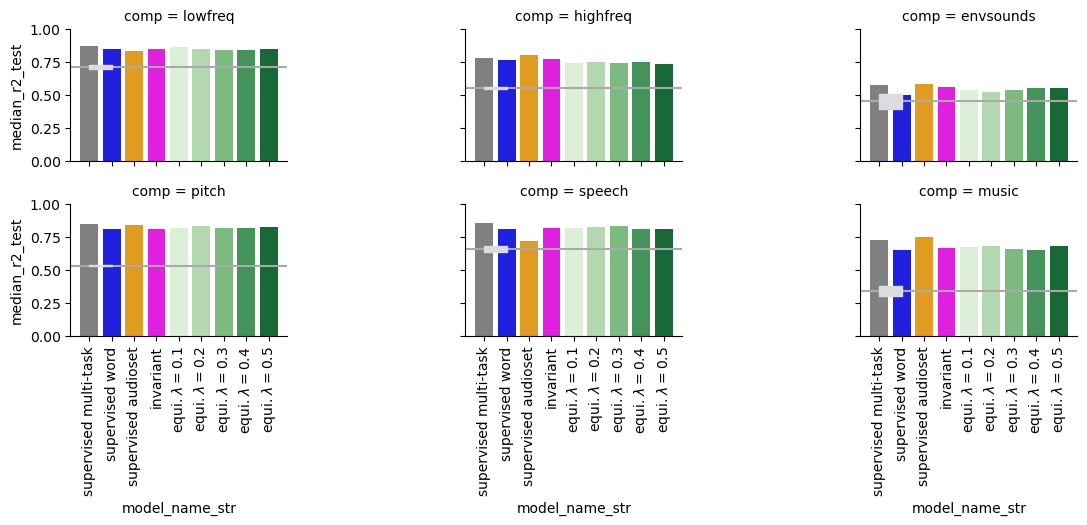

In [69]:

to_plot = results_df[~results_df.model_name_str.str.contains("8e|spectemp")]
model_name_list = to_plot['model_name_str'].unique()

hue_order = [
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

model_names_for_x = []

for name in hue_order:
    name = name.replace('kell2018 ', '')
    if "e-01" in name:
        eq, lmbda = name.split(' ')
        name = f"equi. $\\lambda=${float(lmbda)}"
    model_names_for_x.append(name)
    
# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'



eq_model_list = hue_order[4:]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

hue_dict = {**hue_dict, **equi_color_dict}

spectemp_vals = results_df[results_df.model_name_str.str.contains("spectemp")]

g = sns.catplot(data=to_plot, kind='bar',
                order = hue_order,
                x='model_name_str',
                y='median_r2_test',
                hue='model_name_str',
                palette=hue_dict,
                col='comp', col_wrap=3,
                aspect=2,height=2,)

for ax in g.axes.flat:
    component = ax.get_title().split(' = ')[-1]
    med_r2, error = spectemp_vals.loc[spectemp_vals.comp == component, ['median_r2_test', 'median_r2_test_std_over_it']].values[0]
    ax.axhline(med_r2, color='darkgrey', zorder=2)
    ax.fill_between([0,1],med_r2 - error, med_r2 +  error, color='gainsboro', zorder=2)


g.set(ylim=(0,1),)
g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')


In [61]:
error

np.float64(0.0397080099936479)

In [41]:
spectemp_vals

,Unnamed: 0,comp,median_r2_test,pos,rel_pos,nit,median_r2_test_std_over_it,pos_std_over_it,rel_pos_std_over_it,nit.1,...,comp_idx,subj_idx,comp.1,aggregation,yerr_type,value_of_interest,sort_by,add_savestr,n_models,model_name_str
60,0,lowfreq,0.709552,1.0,1.0,10,0.013683,NaN,NaN,10,...,lowfreq,0.0,lowfreq,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
61,1,highfreq,0.553576,1.0,1.0,10,0.007057,NaN,NaN,10,...,highfreq,1.0,highfreq,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
62,2,envsounds,0.449090,1.0,1.0,10,0.054415,NaN,NaN,10,...,envsounds,2.0,envsounds,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
63,3,pitch,0.531906,1.0,1.0,10,0.005781,NaN,NaN,10,...,pitch,3.0,pitch,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
64,4,speech,0.658012,1.0,1.0,10,0.022393,NaN,NaN,10,...,speech,4.0,speech,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
65,5,music,0.340575,1.0,1.0,10,0.039708,NaN,NaN,10,...,music,5.0,music,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
66,0,lowfreq,0.709552,1.0,1.0,10,0.013683,NaN,NaN,10,...,lowfreq,0.0,lowfreq,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
67,1,highfreq,0.553576,1.0,1.0,10,0.007057,NaN,NaN,10,...,highfreq,1.0,highfreq,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
68,2,envsounds,0.449090,1.0,1.0,10,0.054415,NaN,NaN,10,...,envsounds,2.0,envsounds,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
69,3,pitch,0.531906,1.0,1.0,10,0.005781,NaN,NaN,10,...,pitch,3.0,pitch,CV-splits-nit-10,median_r2_test_sem_over_it,median_r2_test,performance,NaN,72,spectemp
